# Library
Xử lý dữ liệu: **pandas, numpy**  
Visualize: **matplot, seaborn**  
Xuất mô hình: **joblib**  
Khác: **json, datetime, os**  
Mô hình, huấn luyện và đánh giá: **scikit learn**  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import json
from datetime import datetime
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

# Loading Data
Tải dữ liệu để huấn luyện (từ silver data)  

In [2]:
# files = ["preprocessed_data_1.json", "preprocessed_data_2.json", "preprocessed_data_3.json"]
files = ["preprocessed_data_modified.json"]
# files = ["dataset.json"]
data = []
for file in files:
    with open(file, "r", encoding="utf-8") as f:
        data += [pd.DataFrame(json.load(f))]

df = pd.concat(data, ignore_index=True)
print(df.head())
print(len(df))

             start station              end station      hour  week day  \
0          Bến xe An Sương                  Tân Sơn  4.650000         6   
1                  Tân Sơn    Ngã tư Thoại Ngọc Hầu  5.200000         6   
2    Ngã tư Thoại Ngọc Hầu  Công ty Bông Bạch Tuyết  5.333333         6   
3  Công ty Bông Bạch Tuyết       Chợ Trần Văn Quang  5.350000         6   
4       Chợ Trần Văn Quang            Chợ Tân Phước  5.366667         6   

   distance (m)  duration (s)  
0   3928.179591          1966  
1   3415.784008           452  
2    517.287167           100  
3    353.987667            64  
4    853.944399           106  
264212


# Preprocessing
Thực hiện sàn lọc thêm để phù hợp cho dữ liệu huấn luyện bao gồm:
* Làm sạch
* Thêm feature: avg_duration

Con số 3000 ở đây là theo quy định pháp luật: tuyến xe buýt có các điểm dừng đón, trả khách. Khoảng cách tối đa giữa hai điểm dừng đón, trả khách liền kề trong nội thành, nội thị là 700m, ngoại thành, ngoại thị là 3000m. 3000m ở đây là worst case

In [3]:
df = df[(df["distance (m)"] <= 3000) & (df["distance (m)"] > 100) & (df["duration (s)"] <= 1800) & (df['duration (s)'] > 10)]
print(len(df))

223407


In [4]:
df["route"] = df["start station"] + "_" + df["end station"]

# Preprocessing numerical feature 
df["weekend"] = (df["week day"]>=5).astype(int)
df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)

df = df.drop(columns=["week day", "hour"])

print(df.head(5))
print(len(df))

df.to_json("dataset.json", orient="records", force_ascii=False, indent=4)

             start station              end station  distance (m)  \
2    Ngã tư Thoại Ngọc Hầu  Công ty Bông Bạch Tuyết    517.287167   
3  Công ty Bông Bạch Tuyết       Chợ Trần Văn Quang    353.987667   
4       Chợ Trần Văn Quang            Chợ Tân Phước    853.944399   
5            Chợ Tân Phước    Vòng xoay Lê Đại Hành    315.499277   
6    Vòng xoay Lê Đại Hành                  Parkson    872.258094   

   duration (s)                                          route  weekend  \
2           100  Ngã tư Thoại Ngọc Hầu_Công ty Bông Bạch Tuyết        1   
3            64     Công ty Bông Bạch Tuyết_Chợ Trần Văn Quang        1   
4           106               Chợ Trần Văn Quang_Chợ Tân Phước        1   
5            50            Chợ Tân Phước_Vòng xoay Lê Đại Hành        1   
6           110                  Vòng xoay Lê Đại Hành_Parkson        1   

   hour_sin  hour_cos  
2  0.984808  0.173648  
3  0.985556  0.169350  
4  0.986286  0.165048  
5  0.987688  0.156434  
6  0.988362  0

Chia dataset thành train và test trong đó test chiếm 20%.  
Thực hiện các mô hình để dự đoán thời gian đi từ trạm A đến trạm B dựa theo các feature: {distance, weekend, hour -> (sin,cos), avg_duration, start station, end station}  
Mà trong đó start và end station được mã hóa thành dạng vector (One Hot Encoding)  
Tóm lại: ***Dataset này là dataset ít nhiễu, có quan hệ gần tuyến tính, có một historiacal feature và gần dạng additive model***

Nhóm thực hiện 3 mô hình nhằm so sánh và đánh giá.

In [5]:
target = "duration (s)"
categorical_cols = ["start station", "end station"]
numeric_cols = ["distance (m)", "weekend", "hour_sin", "hour_cos", "avg_duration_route"]

lr_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numeric_cols)
    ]
)

rf_gb_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", 'passthrough', numeric_cols)
    ]
)

In [6]:
# Preprocess pre historical feature after split for avoid Data Leakage
def add_historical_features(train_df, test_df):

    route_avg = train_df.groupby("route")["duration (s)"].mean()
    start_avg = train_df.groupby("start station")["duration (s)"].mean()
    end_avg   = train_df.groupby("end station")["duration (s)"].mean()
    global_avg = train_df["duration (s)"].mean()

    for df_ in [train_df, test_df]:
        
        df_["avg_duration_route"] = df_["route"].map(route_avg)
        df_["avg_start_route"] = df_["start station"].map(start_avg)
        df_["avg_end_route"] = df_["end station"].map(end_avg)

        df_["avg_duration_route"] = (
            df_["avg_duration_route"]
            .fillna(df_["avg_start_route"])
            .fillna(df_["avg_end_route"])
            .fillna(global_avg)
        )

    return train_df, test_df

In [7]:
# Split data
split_idx = int(len(df)*0.8)

train_df = df.iloc[:split_idx]
test_df  = df.iloc[split_idx:]

train_df, test_df = add_historical_features(train_df, test_df)
his_df = train_df[["route", "avg_duration_route"]]
his_df.to_json("avg_duration.json", orient="records", force_ascii=False, indent=4)

X_train = train_df.drop(columns=[target])
Y_train = train_df[target].values

X_test = test_df.drop(columns=[target])
Y_test = test_df[target].values

C:\Users\thanh\AppData\Local\Temp\ipykernel_9748\820358073.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_["avg_duration_route"] = df_["route"].map(route_avg)
C:\Users\thanh\AppData\Local\Temp\ipykernel_9748\820358073.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_["avg_start_route"] = df_["start station"].map(start_avg)
C:\Users\thanh\AppData\Local\Temp\ipykernel_9748\820358073.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .lo

In [8]:
def routewise_normalized_error(X_test, Y_test, y_pred):
    """
    Compute route-wise normalized MAE and RMSE.

    Parameters
    ----------
    X_test : pd.DataFrame
        Test features containing route column.
    Y_test : array-like
        Ground truth duration.
    y_pred : array-like
        Predicted duration.

    Returns
    -------
    final_nmae : float
        Route-wise normalized MAE
    final_nrmse : float
        Route-wise normalized RMSE
    """

    df_eval = pd.DataFrame({
        "route": X_test["route"].values,
        "y_true": np.asarray(Y_test),
        "y_pred": np.asarray(y_pred)
    })

    route_scores = []

    for _, group in df_eval.groupby("route"):

        err = group["y_true"] - group["y_pred"]
        mean_duration = group["y_true"].mean()

        # avoid division by zero
        denom = mean_duration + 1e-8

        nmae_r = np.mean(np.abs(err)) / denom
        nrmse_r = np.sqrt(np.mean(err**2)) / denom

        route_scores.append((nmae_r, nrmse_r))

    route_scores = np.array(route_scores)

    final_nmae = route_scores[:, 0].mean()
    final_nrmse = route_scores[:, 1].mean()

    return final_nmae, final_nrmse

## Linear Regression
Mô hình hồi quy tuyến tính được hiện thực như một baseline để so sánh, đánh giá.  
Cần phải scale các giá trị số học.

**Hồi quy tuyến tính**: giả định quan hệ tuyến tính giữa X,Y
- Ổn định với bài toán ETA ít nhiễu
- Các feature gần tuyến tính (duration ~ distance)

In [9]:
linear_model = Pipeline([
    ("preprocess", lr_preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, Y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [10]:
pred_lr = linear_model.predict(X_test)
# metric
lr_nmae, lr_nrmse = routewise_normalized_error(X_test, Y_test, pred_lr)
lr_r2 = r2_score(Y_test, pred_lr)

lr_result = ["Linaer Regression", 
             lr_nmae, 
             lr_nrmse, 
             lr_r2]

print("NMAE: ", lr_result[1])
print("NRMSE: ", lr_result[2])
print("R2: ", lr_result[3])

NMAE:  0.2980825697582554
NRMSE:  0.3479117829403033
R2:  0.595101888764257


In [11]:
# Tạo ra file
joblib.dump(linear_model, "linear_regression_model.pkl")

['linear_regression_model.pkl']

## Random Forest
Mô hình random forest thuộc nhóm ensemble sinh nhiều cây decision tree rồi thực hiện gộp lại (avg) (học song song)

**Random Forest (100 cây)**: Học tốt được các quan hệ phi tuyến tính
- Vẫn ổn định với dataset có nhiễu
- Hiệu năng tốt hơn so với linear regression
- Ít bị overfitting

In [12]:
rf_model = Pipeline([
    ("preprocess", rf_gb_preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        verbose=1
    ))
])

rf_model.fit(X_train, Y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  9.9min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 25.9min finished


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


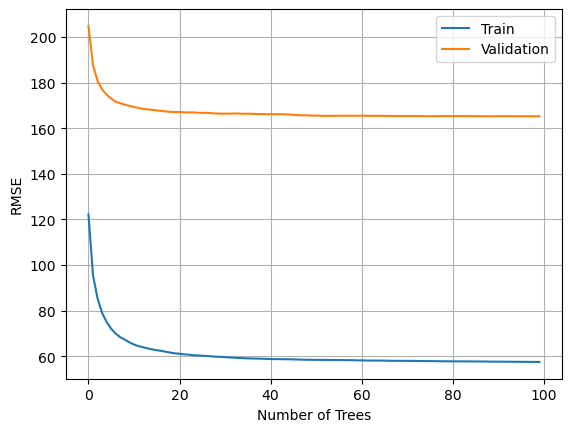

In [13]:
# Learning Curve
rf = rf_model.named_steps["model"]

X_train_trans = rf_model.named_steps["preprocess"].transform(X_train)
X_test_trans   = rf_model.named_steps["preprocess"].transform(X_test)

train_loss = []
test_loss = []

train_pred = np.zeros(len(Y_train))
test_pred = np.zeros(len(Y_test))

for i, tree in enumerate(rf.estimators_, start=1):

    train_pred += tree.predict(X_train_trans)
    test_pred += tree.predict(X_test_trans)

    avg_train = train_pred / i
    avg_test = test_pred / i

    train_loss.append(root_mean_squared_error(Y_train, avg_train))
    test_loss.append(root_mean_squared_error(Y_test, avg_test))

plt.plot(train_loss, label="Train")
plt.plot(test_loss, label="Validation")
plt.xlabel("Number of Trees")
plt.ylabel("RMSE")
plt.legend()
plt.grid()
plt.show()

In [14]:
pred_rf = rf_model.predict(X_test)

rf_nmae, rf_nrmse = routewise_normalized_error(X_test, Y_test, pred_rf)
rf_r2 = r2_score(Y_test, pred_rf)

rf_result = ["Random Forest", 
             rf_nmae, 
             rf_nrmse, 
             rf_r2]

print("MAE:", rf_result[1])
print("RMSE:", rf_result[2])
print("R2:", rf_result[3])

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.7s finished


MAE: 0.2803220817865441
RMSE: 0.3391867400218103
R2: 0.6070385250988622


In [15]:
# Tạo ra file
joblib.dump(rf_model, "randomforest_model.pkl")

['randomforest_model.pkl']

## Gradient Boosting
Mô hình random forest thuộc nhóm ensemble cải tiến từ error của cây tạo trước đó (học tuần tự sửa sai)

**Gradient Boosting (300 lần sửa)**: Học tốt được các quan hệ phi tuyến tính
- Vẫn ổn định với dataset có nhiễu
- Hiệu năng tốt hơn so với randomforest
- Cực phù hợp với dataset

In [16]:
gb_model = Pipeline([
    ("preprocess", rf_gb_preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
        verbose=1
    ))
])

gb_model.fit(X_train, Y_train)

      Iter       Train Loss   Remaining Time 
         1       67288.1096            1.74m
         2       63207.8416            1.68m
         3       59509.2483            1.72m
         4       56166.0688            1.69m
         5       53138.4124            1.69m
         6       50401.1652            1.67m
         7       47922.2953            1.65m
         8       45686.5519            1.65m
         9       43657.2106            1.64m
        10       41823.6296            1.63m
        20       30697.8613            1.69m
        30       26459.2245            1.58m
        40       24794.4264            1.53m
        50       24077.7522            1.48m
        60       23603.6088            1.43m
        70       23261.0368            1.36m
        80       23044.3994            1.28m
        90       22911.5194            1.21m
       100       22760.2968            1.14m
       200       22079.8808           33.46s
       300       21754.9139            0.00s


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


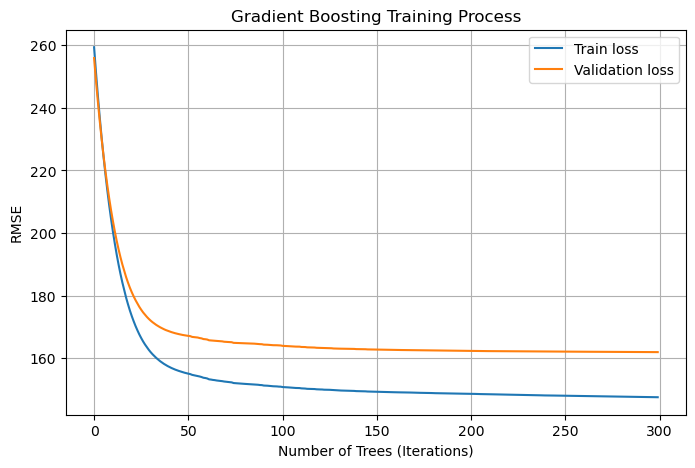

In [17]:
# Learning Curve
gb = gb_model.named_steps["model"]

X_train_trans = gb_model.named_steps["preprocess"].transform(X_train)
X_test_trans  = gb_model.named_steps["preprocess"].transform(X_test)

train_loss = []
test_loss = []

for y_pred_train, y_pred_test in zip(
        gb.staged_predict(X_train_trans),
        gb.staged_predict(X_test_trans)):
    
    train_loss.append(
        root_mean_squared_error(Y_train, y_pred_train)
    )

    test_loss.append(
        root_mean_squared_error(Y_test, y_pred_test)
    )

plt.figure(figsize=(8,5))
plt.plot(train_loss, label="Train loss")
plt.plot(test_loss, label="Validation loss")

plt.xlabel("Number of Trees (Iterations)")
plt.ylabel("RMSE")
plt.title("Gradient Boosting Training Process")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
pred_gb = gb_model.predict(X_test)

gb_nmae, gb_nrmse = routewise_normalized_error(X_test, Y_test, pred_gb)
gb_r2 = r2_score(Y_test, pred_gb)

gb_result = ["Gradient Boosting", 
             gb_nmae, 
             gb_nrmse, 
             gb_r2]

print("MAE:", gb_result[1])
print("RMSE:", gb_result[2])
print("R2:", gb_result[3])

MAE: 0.2932975958762385
RMSE: 0.34216888316099325
R2: 0.6226956601570042


In [19]:
# Tạo ra file
joblib.dump(rf_model, "gradientboosting_model.pkl")

['gradientboosting_model.pkl']

# Comparasion
## So sánh và đánh giá 3 giải thuật linear regression, random forest và gradient boosting:
* Lấy linear regression làm baseline có thể thấy hiệu năng tằng dần từ linear regression -> random forest -> gradient boosting 
Với R2 ở cả ba mô hình đều đặt ở khoảng >60%. Điều này nghĩa là dataset hiện tại đã gần tuyến tính chỉ có một số feature là phi tuyến tính (hour -> giờ cao điểm; week end -> đi học đi chơi?;...) kèm theo preprocessing loại bỏ các nhiễu (có duration, distance quá lớn hoặc quá nhỏ) nên linear regression cũng mang lại hiệu năng tương đối.  
* Random Forest vốn mạnh nhờ khả năng giảm phương sai, tránh overfit và có thể học được các quan hệ phi tuyến tính nên hiệu năng là tốt hơn so với linear regression (đặc biệt là nếu dữ liệu có nhiều noise điểm mạnh của random forest càng được phát huy)  
* Cuối cùng là Gradient Boosting một mô hình có thể gọi là rất hợp với bài toán mà khung ban đầu đã gần tuyến tính chỉ cần sửa vài điểm có thể tốt hơn.

In [20]:
result = [lr_result, rf_result, gb_result]
result_df = pd.DataFrame(
    result,
    columns=["Model", "MAE", "RMSE", "R2"]
)
print(result_df)

               Model       MAE      RMSE        R2
0  Linaer Regression  0.298083  0.347912  0.595102
1      Random Forest  0.280322  0.339187  0.607039
2  Gradient Boosting  0.293298  0.342169  0.622696


## Visualization & Chart

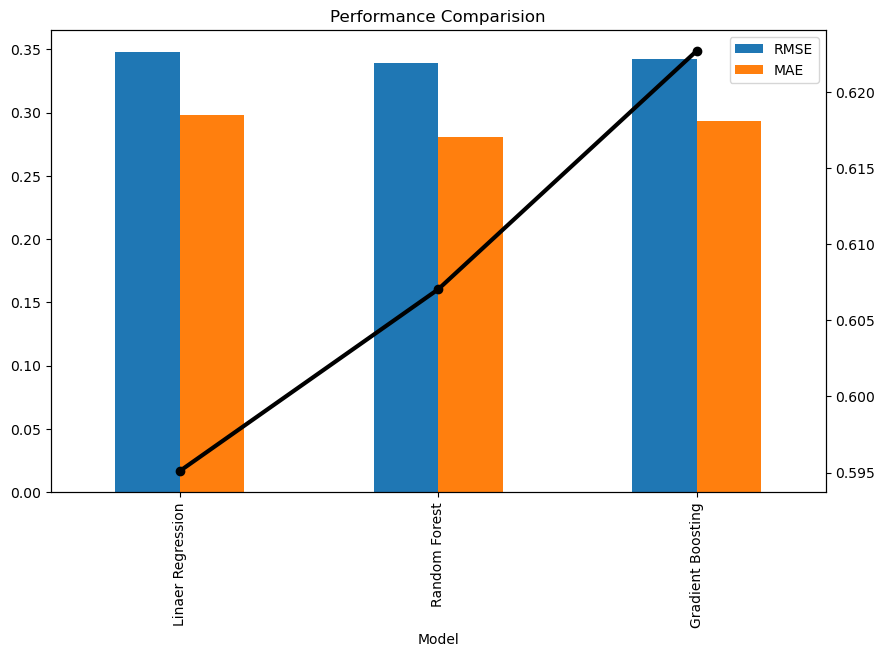

In [21]:
metrics = ["MAE", "RMSE", "R2"]

fig, ax1 = plt.subplots(figsize=(10,6))
result_df.plot(
    x="Model",
    y=["RMSE", "MAE"],
    kind="bar",
    ax=ax1
)

ax2 = ax1.twinx()

ax2.plot(result_df["Model"],
         result_df["R2"],
         color="black",
         marker="o",
         linewidth=3
)

plt.title("Performance Comparision")
plt.show()

## Cải thiện, mở rộng
Bàn kỹ hơn về R2, nói dễ hiểu thì R2 cho thấy khả năng giải thích các sai số mà mô hình dự đoán trong bài toán và các mô hình hiện tại R2 chỉ ở khoảng 70% nó không có nghĩa mô hình yếu mà là các feature chưa đủ và còn các feature ẩn có thể khai thác thêm. Thực tế là việc dự đoán thời gian di chuyển còn phụ thuộc thêm nhiều yếu tố khác mà trong dataset chưa lấy được (thời gian dừng ở trạm? đoạn đường phía trước có kẹt không? Mật độ giao thông hiện tại?...)
Ngoài ra bài toán có thể mở rộng từ ETA (estimated time arrial) sang bài toán về dự đoán độ trễ mà phụ thuộc nhiều hơn các historical feature khiến bài toán bây giờ tiến gần đến bài toán semi-time series.